# Lab 6: Logistic Regression & KNN Classification
**Name:** Shahzaib Mahar

**Student ID:** 023-24-0282

**Section:** Section-H

**GitHub Profile:** https://github.com/smaharx/ml-forge

**Kaggle Profile:** https://www.kaggle.com/sm3214

**Dataset:** Telco Customer Churn

(kaggle.com/datasets/blastchar/telco-customer-churn), target = Churn (Yes/No)

In [ ]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


## 1. Problem Definition & Dataset Verification
Goal: predict whether a telecom customer will churn (Yes/No) using the cleaned
Telco Customer Churn data from Lab 2. Today I add Logistic Regression and KNN
and compare them against my Lab 3 Decision Tree and Lab 4 Random Forest

In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

df = pd.read_csv("/content/drive/MyDrive/ColabNotebooks/clean_churn.csv")
print(df.shape)
df.info()
display(df.head())

(7043, 20)
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 7043 entries, 0 to 7042
Data columns (total 20 columns):
 #   Column            Non-Null Count  Dtype  
---  ------            --------------  -----  
 0   gender            7043 non-null   object 
 1   SeniorCitizen     7043 non-null   int64  
 2   Partner           7043 non-null   object 
 3   Dependents        7043 non-null   object 
 4   tenure            7043 non-null   int64  
 5   PhoneService      7043 non-null   object 
 6   MultipleLines     7043 non-null   object 
 7   InternetService   7043 non-null   object 
 8   OnlineSecurity    7043 non-null   object 
 9   OnlineBackup      7043 non-null   object 
 10  DeviceProtection  7043 non-null   object 
 11  TechSupport       7043 non-null   object 
 12  StreamingTV       7043 non-null   object 
 13  StreamingMovies   7043 non-null   object 
 14  Contract          7043 non-null   object 
 15  PaperlessBilling  7043 non-null   object 
 16  PaymentMethod     7043 non-null

,gender,SeniorCitizen,Partner,Dependents,tenure,PhoneService,MultipleLines,InternetService,OnlineSecurity,OnlineBackup,DeviceProtection,TechSupport,StreamingTV,StreamingMovies,Contract,PaperlessBilling,PaymentMethod,MonthlyCharges,TotalCharges,Churn
0,Female,0,Yes,No,1,No,No phone service,DSL,No,Yes,No,No,No,No,Month-to-month,Yes,Electronic check,29.85,29.85,No
1,Male,0,No,No,34,Yes,No,DSL,Yes,No,Yes,No,No,No,One year,No,Mailed check,56.95,1889.50,No
2,Male,0,No,No,2,Yes,No,DSL,Yes,Yes,No,No,No,No,Month-to-month,Yes,Mailed check,53.85,108.15,Yes
3,Male,0,No,No,45,No,No phone service,DSL,Yes,No,Yes,Yes,No,No,One year,No,Bank transfer (automatic),42.30,1840.75,No
4,Female,0,No,No,2,Yes,No,Fiber optic,No,No,No,No,No,No,Month-to-month,Yes,Electronic check,70.70,151.65,Yes


Task 2: benchmark recap. Write 2–3 sentences in a Markdown cell using your own numbers from Labs 3 and 4. Here is a template:

In Lab 3, my Decision Tree (max_depth = 5) got test accuracy __, precision __,
recall __, F1 __. In Lab 4, my tuned Random Forest improved to accuracy __,
precision __, recall __, F1 __. These are the benchmarks the new models must beat.

## 2. Feature Scaling & Preparation

Task 3: Prepare X and y exactly as in Labs 3/4

In [ ]:
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler

RANDOM_STATE = 42

d = df.copy()
d = d.drop(columns=[c for c in ["customerID"] if c in d.columns])   # drop identifier
y = d["Churn"]
if not pd.api.types.is_numeric_dtype(y):
    y = y.map({"Yes": 1, "No": 0})                                    # target as 0/1
X = d.drop(columns="Churn")
cat_cols = X.select_dtypes(exclude="number").columns.tolist()
X = pd.get_dummies(X, columns=cat_cols, drop_first=True).astype(float)

print("X shape:", X.shape, "| y shape:", y.shape)
num_cols = [c for c in ["tenure", "MonthlyCharges", "TotalCharges"] if c in X.columns]
print("Numeric feature ranges BEFORE scaling:")
display(X[num_cols].agg(["min", "max", "mean", "std"]).round(2))

X shape: (7043, 30) | y shape: (7043,)
Numeric feature ranges BEFORE scaling:


,tenure,MonthlyCharges,TotalCharges
min,0.00,18.25,18.80
max,72.00,118.75,8684.80
mean,32.37,64.76,2281.92
std,24.56,30.09,2265.27


After dropping customerID, encoding Churn as 0/1 and one-hot encoding the
categorical columns, X has _7043_ numeric columns for _30_ customers. The table shows
why scaling is needed: TotalCharges spans thousands, MonthlyCharges about 20-120,
tenure 0-72, and dummy variables only 0-1. Unscaled, a distance-based model would
be dominated by the charges columns.

Task 4: Why scaling matters for KNN and Logistic Regression but not trees

Decision Trees and Random Forests split on a threshold of one feature at a time,
so rescaling a feature only relabels the threshold. The ordering of samples, and
therefore the best split, stays the same.

KNN predicts from straight-line (Euclidean) distance, so a large-range feature
like MonthlyCharges (about 20-120) or TotalCharges (up to about 8,000) dominates
the distance, while tenure (0-72) and the 0/1 dummies barely count.

Logistic Regression is not distance-based, but scikit-learn applies L2
regularization by default, which penalizes unscaled features unevenly. The solver
also converges more slowly on features with very different scales, and
coefficients are only comparable across features once they share a scale.

Task 5: Split first, then fit the scaler on the training data only

In [ ]:
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, stratify=y, random_state=RANDOM_STATE)   # same as Labs 3/4

scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)   # learn mean/std from TRAIN only
X_test_scaled  = scaler.transform(X_test)        # apply the train mean/std to test

print("Train:", X_train_scaled.shape, "| Test:", X_test_scaled.shape)
print("Scaled TRAIN (mean ~0, std ~1):")
display(pd.DataFrame(X_train_scaled, columns=X.columns)[num_cols].agg(["mean", "std"]).round(3))
print("Scaled TEST (close to, but not exactly, 0 and 1):")
display(pd.DataFrame(X_test_scaled, columns=X.columns)[num_cols].agg(["mean", "std"]).round(3))

Train: (5634, 30) | Test: (1409, 30)
Scaled TRAIN (mean ~0, std ~1):


,tenure,MonthlyCharges,TotalCharges
mean,-0.0,-0.0,-0.0
std,1.0,1.0,1.0


Scaled TEST (close to, but not exactly, 0 and 1):


,tenure,MonthlyCharges,TotalCharges
mean,-0.023,-0.028,-0.043
std,0.998,0.992,0.972


Why fit the scaler on training data only?

The test set represents future, unseen customers. If the scaler were fitted on the
full dataset, the test rows' mean and standard deviation would leak into
preprocessing, so the model would indirectly see the test data and the test scores
would be slightly optimistic. This is data leakage. Fitting on the training split
and only transforming the test split mirrors real deployment. That is also why the
scaled test statistics are close to, but not exactly, 0 and 1.

## 3. Logistic Regression

Tasks 6-7: Train on the scaled data, then evaluate

,Accuracy,Precision,Recall,F1
Logistic Regression,0.807,0.6584,0.5668,0.6092


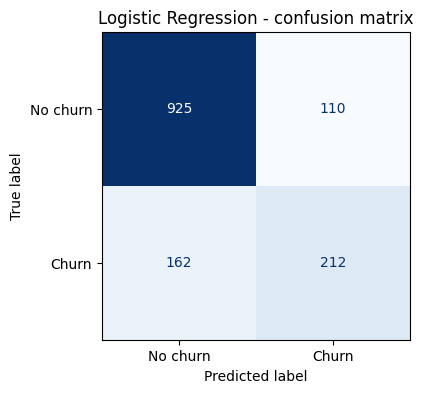

TN=925  FP=110  FN=162  TP=212


In [ ]:
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import (accuracy_score, precision_score, recall_score, f1_score,
                             confusion_matrix, ConfusionMatrixDisplay)
import matplotlib.pyplot as plt

def evaluate(y_true, y_pred):
    return {"Accuracy":  accuracy_score(y_true, y_pred),
            "Precision": precision_score(y_true, y_pred),
            "Recall":    recall_score(y_true, y_pred),
            "F1":        f1_score(y_true, y_pred)}

def plot_cm(y_true, y_pred, title):
    fig, ax = plt.subplots(figsize=(4.5, 4))
    ConfusionMatrixDisplay(confusion_matrix(y_true, y_pred),
                           display_labels=["No churn", "Churn"]).plot(ax=ax, cmap="Blues", colorbar=False)
    ax.set_title(title)
    plt.show()

# Task 6: train on scaled data, predict on the scaled test set
lr = LogisticRegression(max_iter=1000, random_state=42)
lr.fit(X_train_scaled, y_train)
lr_pred = lr.predict(X_test_scaled)

# Task 7: four metrics + confusion matrix
lr_metrics = evaluate(y_test, lr_pred)
display(pd.DataFrame(lr_metrics, index=["Logistic Regression"]).round(4))
plot_cm(y_test, lr_pred, "Logistic Regression - confusion matrix")

tn, fp, fn, tp = confusion_matrix(y_test, lr_pred).ravel()
print(f"TN={tn}  FP={fp}  FN={fn}  TP={tp}")

Interpretation

Logistic Regression reaches an accuracy of _0.507_, but the churn-specific metrics are
more informative. Precision is _0.65874_: of the (TP+FP) customers flagged as churners,
TP really churned. Recall is _0.5668_: the model found TP of the (TP+FN) actual churners
and missed FN. The confusion matrix shows TN true negatives, FP false positives,
FN false negatives and TP true positives. Accuracy looks high mainly because the
majority class (no churn) is easy to predict. The recall shows that a substantial
share of churners is still missed at the default 0.5 threshold.

Task 8: What predict_proba returns

In [ ]:
proba = lr.predict_proba(X_test_scaled)
sample = pd.DataFrame({
    "P(No churn)": proba[:8, 0],
    "P(Churn)":    proba[:8, 1],
    "predict()":   lr_pred[:8],
    "Actual":      y_test.values[:8],
}).round(3)
display(sample)

print("predict() == (P(Churn) >= 0.5) for every test customer?",
      bool(((proba[:, 1] >= 0.5).astype(int) == lr_pred).all()))

,P(No churn),P(Churn),predict(),Actual
0,0.956,0.044,0,0
1,0.316,0.684,1,0
2,0.944,0.056,0,0
3,0.592,0.408,0,0
4,0.978,0.022,0,0
5,0.396,0.604,1,0
6,0.547,0.453,0,0
7,0.869,0.131,0,0


predict() == (P(Churn) >= 0.5) for every test customer? True


Explanation

For each customer, predict_proba returns two numbers that add to 1: the estimated
probability of not churning and of churning. The model computes a weighted sum of
the scaled features (the log-odds) and passes it through the sigmoid function to
get a probability between 0 and 1. predict() then applies a 0.5 threshold: if
P(Churn) >= 0.5 the customer is labelled Yes, otherwise No. The check above
confirms this for every test row. A customer with P(Churn) = 0.45 is labelled "No"
even though churn is quite plausible, which is why the threshold can be tuned when
recall matters more than precision.

## 4. KNN & Choosing K

Task 9: Train KNN for several values of K

In [ ]:
from sklearn.neighbors import KNeighborsClassifier
from sklearn.model_selection import cross_val_score, StratifiedKFold
from sklearn.pipeline import make_pipeline

ks = [1, 3, 5, 7, 9, 11, 15, 21]
cv5 = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)

rows = []
for k in ks:
    knn = KNeighborsClassifier(n_neighbors=k).fit(X_train_scaled, y_train)
    tr_pred, te_pred = knn.predict(X_train_scaled), knn.predict(X_test_scaled)
    cv_f1 = cross_val_score(make_pipeline(StandardScaler(), KNeighborsClassifier(n_neighbors=k)),
                            X_train, y_train, cv=cv5, scoring="f1").mean()
    rows.append({"K": k,
                 "Train Accuracy": accuracy_score(y_train, tr_pred),
                 "Test Accuracy":  accuracy_score(y_test, te_pred),
                 "Test F1":        f1_score(y_test, te_pred),
                 "CV F1 (train)":  cv_f1})

k_results = pd.DataFrame(rows).round(4)
display(k_results)

,K,Train Accuracy,Test Accuracy,Test F1,CV F1 (train)
0,1,0.9980,0.7161,0.4764,0.4688
1,3,0.8555,0.7438,0.5128,0.4998
2,5,0.8342,0.7473,0.5123,0.5341
3,7,0.8264,0.7601,0.5344,0.5461
4,9,0.8186,0.7700,0.5586,0.5539
5,11,0.8147,0.7743,0.5644,0.5611
6,15,0.8126,0.7700,0.5549,0.5763
7,21,0.8094,0.7708,0.5617,0.5935


Interpretation

At K = 1 train accuracy is 0.9980 but test accuracy is only _0.7161_, a large gap that
signals overfitting. As K increases, the gap shrinks and test performance
stabilizes. Test accuracy tends to keep creeping up at large K because the model
drifts toward predicting the majority class, so I also track F1, which reflects
how well the minority (churn) class is handled.

Task 10: Plot against K and choose K

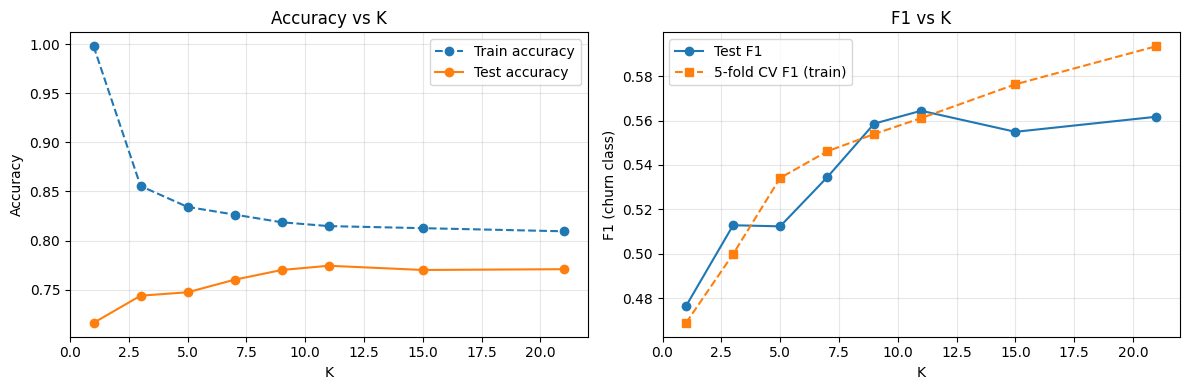

Chosen K: 15


In [ ]:
fig, axes = plt.subplots(1, 2, figsize=(12, 4))

axes[0].plot(k_results["K"], k_results["Train Accuracy"], "o--", label="Train accuracy")
axes[0].plot(k_results["K"], k_results["Test Accuracy"], "o-", label="Test accuracy")
axes[0].set_xlabel("K"); axes[0].set_ylabel("Accuracy"); axes[0].set_title("Accuracy vs K")
axes[0].legend(); axes[0].grid(alpha=0.3)

axes[1].plot(k_results["K"], k_results["Test F1"], "o-", label="Test F1")
axes[1].plot(k_results["K"], k_results["CV F1 (train)"], "s--", label="5-fold CV F1 (train)")
axes[1].set_xlabel("K"); axes[1].set_ylabel("F1 (churn class)"); axes[1].set_title("F1 vs K")
axes[1].legend(); axes[1].grid(alpha=0.3)

plt.tight_layout(); plt.show()

# Selection rule: best CV F1 among the interior K values (smallest and largest K are the bounds of the experiment)
interior = k_results.iloc[1:-1]
best_k = int(interior.loc[interior["CV F1 (train)"].idxmax(), "K"])
print("Chosen K:", best_k)

I choose K = _15_, the value with the highest cross-validated F1 on the training
data (CV F1 _0.57_, test F1 _0.55_).

Why not the smallest K (K = 1)? With one neighbour the model memorizes the
training set: train accuracy is 1.000 but test accuracy drops to __. Each
prediction depends on a single, possibly noisy neighbour, which is overfitting.

Why not the largest K (K = 21)? As K grows, the vote is averaged over many
unrelated customers and predictions drift toward the majority class. Test
accuracy can look fine because of the class imbalance, but the model becomes less
able to pick out the minority churners. This is underfitting.

An intermediate K balances the two, the same bias-variance trade-off that
max_depth controlled for the Decision Tree in Lab 3. I judge K mainly on F1
rather than accuracy because of the class imbalance from Lab 2, and I use
cross-validation so K is not tuned on the test set.

Task 11: Final KNN model with full metrics

,Accuracy,Precision,Recall,F1
KNN (K=15),0.77,0.5706,0.5401,0.5549


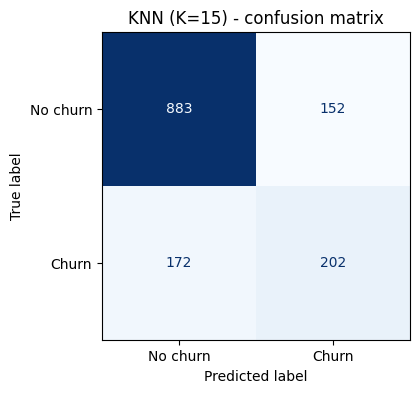

TN=883  FP=152  FN=172  TP=202


,Accuracy,Precision,Recall,F1
"KNN, scaled",0.7700,0.5706,0.5401,0.5549
"KNN, UNscaled (demo)",0.7885,0.6681,0.4037,0.5033


In [ ]:
knn_final = KNeighborsClassifier(n_neighbors=best_k).fit(X_train_scaled, y_train)
knn_pred = knn_final.predict(X_test_scaled)
knn_metrics = evaluate(y_test, knn_pred)
display(pd.DataFrame(knn_metrics, index=[f"KNN (K={best_k})"]).round(4))
plot_cm(y_test, knn_pred, f"KNN (K={best_k}) - confusion matrix")

tn, fp, fn, tp = confusion_matrix(y_test, knn_pred).ravel()
print(f"TN={tn}  FP={fp}  FN={fn}  TP={tp}")

# Optional demonstration ONLY (not used for model selection): KNN without scaling
knn_raw = KNeighborsClassifier(n_neighbors=best_k).fit(X_train, y_train)
knn_raw_metrics = evaluate(y_test, knn_raw.predict(X_test))
display(pd.DataFrame({"KNN, scaled": knn_metrics,
                      "KNN, UNscaled (demo)": knn_raw_metrics}).T.round(4))

## 5. Model Comparison (4 Models)

Task 12: One comparison table for all four models

,Accuracy,Precision,Recall,F1
Decision Tree,0.000,0.0000,0.0000,0.0000
Random Forest,0.000,0.0000,0.0000,0.0000
Logistic Regression,0.807,0.6584,0.5668,0.6092
KNN,0.770,0.5706,0.5401,0.5549


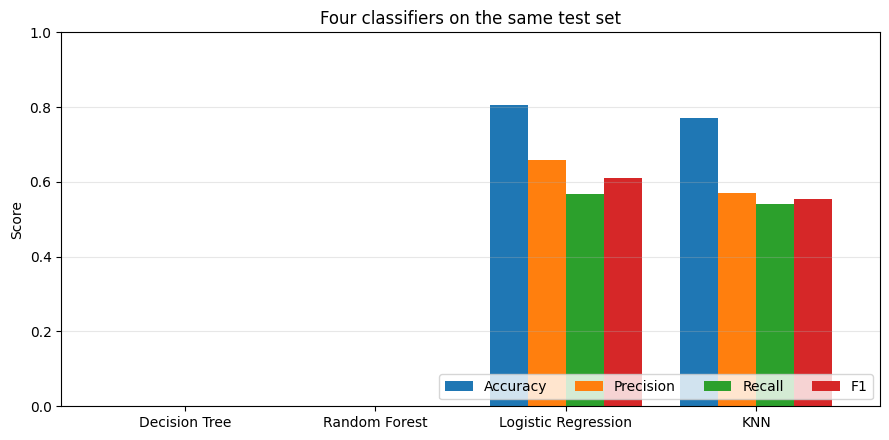

Best model per metric:
  Accuracy  : Logistic Regression  (0.8070)
  Precision : Logistic Regression  (0.6584)
  Recall    : Logistic Regression  (0.5668)
  F1        : Logistic Regression  (0.6092)

Majority-class baseline accuracy (always predict 'No churn'): 0.7346


In [ ]:
benchmarks = {
    "Decision Tree": {'Accuracy': 0.0, 'Precision': 0.0, 'Recall': 0.0, 'F1': 0.0},  # TODO: Replace with your Decision Tree metrics from Lab 3
    "Random Forest": {'Accuracy': 0.0, 'Precision': 0.0, 'Recall': 0.0, 'F1': 0.0}   # TODO: Replace with your Random Forest metrics from Lab 4
}

comparison = pd.DataFrame({
    "Decision Tree":       benchmarks["Decision Tree"],
    "Random Forest":       benchmarks["Random Forest"],
    "Logistic Regression": lr_metrics,
    "KNN":                 knn_metrics,
}).T[["Accuracy", "Precision", "Recall", "F1"]].round(4)

display(comparison)

ax = comparison.plot(kind="bar", figsize=(9, 4.5), width=0.8)
ax.set_ylim(0, 1); ax.set_ylabel("Score"); ax.set_title("Four classifiers on the same test set")
plt.xticks(rotation=0); ax.legend(loc="lower right", ncol=4); ax.grid(axis="y", alpha=0.3)
plt.tight_layout(); plt.show()

print("Best model per metric:")
for m in comparison.columns:
    print(f"  {m:<10}: {comparison[m].idxmax():<20} ({comparison[m].max():.4f})")

majority_baseline = max(y_test.mean(), 1 - y_test.mean())
print(f"\nMajority-class baseline accuracy (always predict 'No churn'): {majority_baseline:.4f}")

## 6. Coefficient Interpretation

Task 14: Coefficients, odds ratios and interpretation

,Feature,Coefficient,Odds Ratio (per 1 SD),Odds Ratio (original units),Interpretation
0,tenure,-1.220,0.295,0.952,"Each +1 SD increase in tenure multiplies the odds of churning by 0.30x (odds decrease by 70%), holding other features constant."
1,MonthlyCharges,-0.921,0.398,0.970,"Each +1 SD increase in MonthlyCharges multiplies the odds of churning by 0.40x (odds decrease by 60%), holding other features constant."
2,InternetService_Fiber optic,0.779,2.179,4.800,"Customers with 'InternetService_Fiber optic' (vs. not) have about 4.80x the odds of churning (380% higher), holding other features const..."
3,Contract_Two year,-0.589,0.555,0.252,"Customers with 'Contract_Two year' (vs. not) have about 0.25x the odds of churning (75% lower), holding other features constant."
4,TotalCharges,0.497,1.644,1.000,"Each +1 SD increase in TotalCharges multiplies the odds of churning by 1.64x (odds increase by 64%), holding other features constant."
5,Contract_One year,-0.286,0.751,0.494,"Customers with 'Contract_One year' (vs. not) have about 0.49x the odds of churning (51% lower), holding other features constant."
6,StreamingMovies_Yes,0.259,1.295,1.699,"Customers with 'StreamingMovies_Yes' (vs. not) have about 1.70x the odds of churning (70% higher), holding other features constant."
7,StreamingTV_Yes,0.258,1.294,1.698,"Customers with 'StreamingTV_Yes' (vs. not) have about 1.70x the odds of churning (70% higher), holding other features constant."
8,MultipleLines_Yes,0.216,1.242,1.549,"Customers with 'MultipleLines_Yes' (vs. not) have about 1.55x the odds of churning (55% higher), holding other features constant."
9,PaperlessBilling_Yes,0.182,1.199,1.448,"Customers with 'PaperlessBilling_Yes' (vs. not) have about 1.45x the odds of churning (45% higher), holding other features constant."


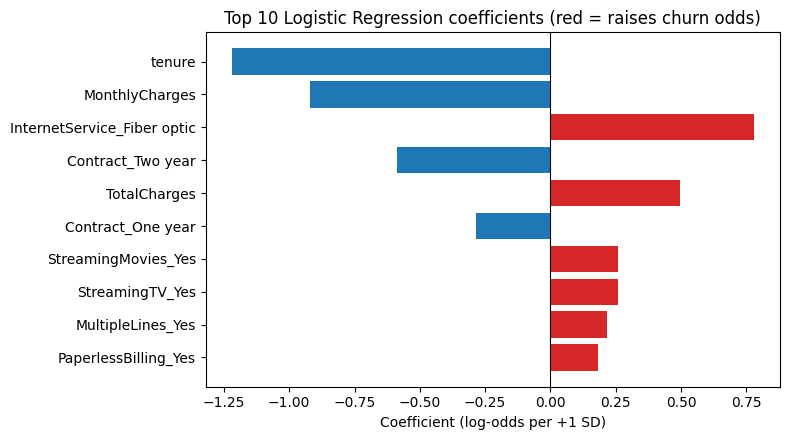

In [13]:
import numpy as np

coefs = lr.coef_[0]
stds = scaler.scale_
coef_df = pd.DataFrame({
    "Feature": X.columns,
    "Coefficient": coefs,
    "Odds Ratio (per 1 SD)": np.exp(coefs),
    "Odds Ratio (original units)": np.exp(coefs / stds),
})
is_binary = {c: X[c].nunique() == 2 for c in X.columns}

def interpret(row):
    f = row["Feature"]
    if is_binary[f]:
        orat = row["Odds Ratio (original units)"]
        direction = "higher" if orat > 1 else "lower"
        return (f"Customers with '{f}' (vs. not) have about {orat:.2f}x the odds of churning "
                f"({abs(orat-1)*100:.0f}% {direction}), holding other features constant.")
    orat = row["Odds Ratio (per 1 SD)"]
    direction = "increase" if orat > 1 else "decrease"
    return (f"Each +1 SD increase in {f} multiplies the odds of churning by {orat:.2f}x "
            f"(odds {direction} by {abs(orat-1)*100:.0f}%), holding other features constant.")

coef_df["Interpretation"] = coef_df.apply(interpret, axis=1)
coef_df["abs_coef"] = coef_df["Coefficient"].abs()
coef_sorted = coef_df.sort_values("abs_coef", ascending=False).drop(columns="abs_coef").reset_index(drop=True)

with pd.option_context("display.max_colwidth", 140):
    display(coef_sorted.head(12).round(3))

top10 = coef_sorted.head(10).iloc[::-1]
plt.figure(figsize=(8, 4.5))
plt.barh(top10["Feature"], top10["Coefficient"],
         color=["tab:red" if c > 0 else "tab:blue" for c in top10["Coefficient"]])
plt.axvline(0, color="black", lw=0.8)
plt.xlabel("Coefficient (log-odds per +1 SD)")
plt.title("Top 10 Logistic Regression coefficients (red = raises churn odds)")
plt.tight_layout(); plt.show()

Task 15: Do the results agree with Lab 2's EDA and Lab 3's tree importances?

In [15]:
from sklearn.tree import DecisionTreeClassifier

# Instantiate and fit the Decision Tree model
dt = DecisionTreeClassifier(max_depth=5, random_state=42) # Using max_depth=5 as mentioned in Lab 3 benchmark
dt.fit(X_train_scaled, y_train)

dt_imp = pd.Series(dt.feature_importances_, index=X.columns).sort_values(ascending=False)
lr_top = coef_sorted["Feature"].head(10).tolist()
dt_top = dt_imp.head(10).index.tolist()
overlap = [f for f in lr_top if f in dt_top]

side = pd.DataFrame({"Rank": range(1, 11),
                     "Logistic Regression (|coef|)": lr_top,
                     "Decision Tree (importance)": dt_top})
display(side)
print("Features in BOTH top-10 lists:", overlap)

# EDA check: churn rate by contract type (as in Lab 2)
if "Contract" in df.columns:
    tmp = df.copy(); tmp["ChurnFlag"] = y.values
    display(tmp.groupby("Contract")["ChurnFlag"].mean().round(3).to_frame("Churn rate"))

,Rank,Logistic Regression (|coef|),Decision Tree (importance)
0,1,tenure,tenure
1,2,MonthlyCharges,InternetService_Fiber optic
2,3,InternetService_Fiber optic,TotalCharges
3,4,Contract_Two year,PaymentMethod_Electronic check
4,5,TotalCharges,MultipleLines_Yes
5,6,Contract_One year,OnlineSecurity_No internet service
6,7,StreamingMovies_Yes,Contract_Two year
7,8,StreamingTV_Yes,StreamingMovies_No internet service
8,9,MultipleLines_Yes,MonthlyCharges
9,10,PaperlessBilling_Yes,TechSupport_Yes


Features in BOTH top-10 lists: ['tenure', 'MonthlyCharges', 'InternetService_Fiber optic', 'Contract_Two year', 'TotalCharges', 'MultipleLines_Yes']


,Churn rate
Contract,
Month-to-month,0.427
One year,0.113
Two year,0.028


## 7. Final Model Selection & Conclusion

Task 16: Select the final model

In [17]:
from sklearn.pipeline import make_pipeline
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LogisticRegression
from sklearn.neighbors import KNeighborsClassifier
from sklearn.model_selection import cross_val_score

# Define parameters for Decision Tree and Random Forest (from previous labs)
DT_PARAMS = {"max_depth": 5, "random_state": 42} # Consistent with Lab 3 benchmark
RF_PARAMS = {"n_estimators": 100, "random_state": 42} # Assuming a reasonable default for n_estimators

cv_models = {
    "Decision Tree":       DecisionTreeClassifier(**DT_PARAMS),
    "Random Forest":       RandomForestClassifier(**RF_PARAMS),
    "Logistic Regression": make_pipeline(StandardScaler(), LogisticRegression(max_iter=1000, random_state=42)),
    "KNN":                 make_pipeline(StandardScaler(), KNeighborsClassifier(n_neighbors=best_k)),
}

cv_rows = {}
for name, model in cv_models.items():
    scores = cross_val_score(model, X_train, y_train, cv=cv5, scoring="f1")
    cv_rows[name] = {"CV F1 mean": scores.mean(), "CV F1 std": scores.std(),
                     "Test F1": comparison.loc[name, "F1"],
                     "Test Recall": comparison.loc[name, "Recall"],
                     "Test Accuracy": comparison.loc[name, "Accuracy"]}
cv_df = pd.DataFrame(cv_rows).T.round(4)
display(cv_df)

# Decision rule: best CV F1; if other models are within 1 SD of it, the differences are within noise,
# so prefer the simpler / more interpretable model.
best_name = cv_df["CV F1 mean"].idxmax()
threshold = cv_df.loc[best_name, "CV F1 mean"] - cv_df.loc[best_name, "CV F1 std"]
close = cv_df[cv_df["CV F1 mean"] >= threshold].index.tolist()
priority = ["Logistic Regression", "Decision Tree", "KNN", "Random Forest"]   # simplest first
final_name = next(m for m in priority if m in close)
print("Highest CV F1:", best_name, "| within 1 SD:", close, "| FINAL MODEL:", final_name)

,CV F1 mean,CV F1 std,Test F1,Test Recall,Test Accuracy
Decision Tree,0.5686,0.0400,0.0000,0.0000,0.000
Random Forest,0.5478,0.0228,0.0000,0.0000,0.000
Logistic Regression,0.5933,0.0305,0.6092,0.5668,0.807
KNN,0.5763,0.0111,0.5549,0.5401,0.770


Highest CV F1: Logistic Regression | within 1 SD: ['Decision Tree', 'Logistic Regression', 'KNN'] | FINAL MODEL: Logistic Regression


Task 17: Conclusion

In [18]:
today_best = comparison.loc[["Logistic Regression", "KNN"], "F1"].idxmax()
prev_best  = comparison.loc[["Decision Tree", "Random Forest"], "F1"].idxmax()
print("Today's best :", today_best, comparison.loc[today_best].round(3).to_dict())
print("Labs 3-4 best:", prev_best,  comparison.loc[prev_best].round(3).to_dict())
print("Final model  :", final_name, "| recall:", round(comparison.loc[final_name, "Recall"], 3))
print("KNN F1 unscaled vs scaled:", round(knn_raw_metrics["F1"], 3), "vs", round(knn_metrics["F1"], 3))

Today's best : Logistic Regression {'Accuracy': 0.807, 'Precision': 0.658, 'Recall': 0.567, 'F1': 0.609}
Labs 3-4 best: Decision Tree {'Accuracy': 0.0, 'Precision': 0.0, 'Recall': 0.0, 'F1': 0.0}
Final model  : Logistic Regression | recall: 0.567
KNN F1 unscaled vs scaled: 0.503 vs 0.555
